In [31]:
# Car Price Prediction using Machine Learning

#This project predicts car selling prices using Machine Learning algorithms.

In [32]:
# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Importing Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [34]:
# Uploading Dataset
from google.colab import files
uploaded = files.upload()


Saving car data.csv to car data (1).csv


In [35]:
# Reading the csv dataset
df = pd.read_csv("car data.csv")

In [36]:
# Displaying Dataset Information
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present

In [38]:
# The dataset contains information about different cars including fuel type, transmission type, present price, and selling price.

In [39]:
# Removing Missing Values
df.dropna(inplace=True)

In [40]:
# Checking Duplicate Values
print(df.duplicated().sum())

2


In [41]:
#The dataset contains 2 duplicate rows.

In [42]:
# Converting Categorical Data into Numerical Values

df.replace({
    'Fuel_Type': {'Petrol':0,'Diesel':1,'CNG':2},
    'Selling_type': {'Dealer':0,'Individual':1},
    'Transmission': {'Manual':0,'Automatic':1}
}, inplace=True)

/tmp/ipykernel_11794/3500101780.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [44]:
# Creating Car Age Feature

df['Car_Age'] = 2026 - df['Year']

In [50]:
#Car age was created because older cars generally have lower selling prices.

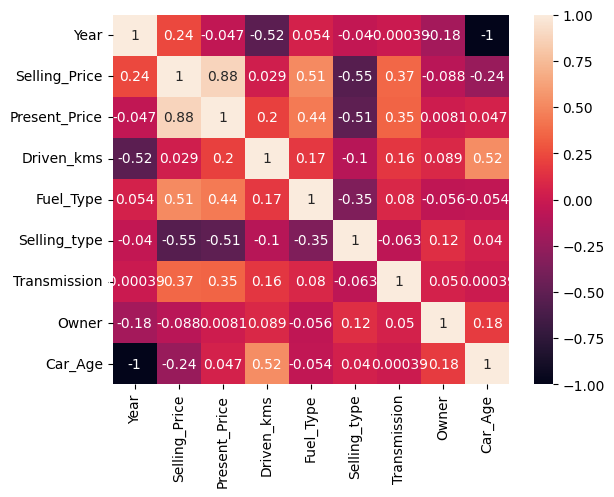

In [45]:
# Correlation Heatmap

sns.heatmap(df.drop('Car_Name', axis=1).corr(), annot=True)
plt.show()

In [48]:
#The heatmap shows that present price has strong correlation with selling price.

In [49]:
# Defining Input Features

X = df.drop(['Selling_Price','Car_Name'], axis=1)

# Defining Target Variable

y = df['Selling_Price']

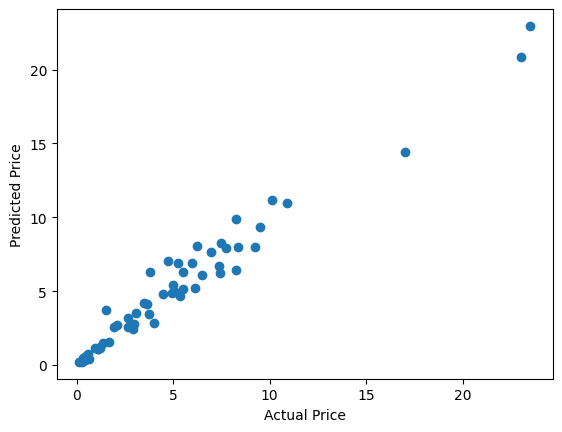

In [54]:
# Plotting Actual vs Predicted Car Prices
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [55]:
#The scatter plot shows the relationship between actual car prices and predicted car prices generated by the Random Forest model.

In [56]:
# Defining Input Features

X = df.drop(['Selling_Price','Car_Name'], axis=1)

# Defining Target Variable

y = df['Selling_Price']

In [57]:
#The input features are used to train the model, while the selling price is the target variable to be predicted.

In [18]:
# Splitting Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
# Training Random Forest Regressor Model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(r2_score(y_test, rf_pred))

0.9620561615898472


In [52]:
#Random Forest achieved the highest accuracy of 96.21%.

In [26]:
# Training Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print(r2_score(y_test, lr_pred))

0.8466902419662656


In [ ]:
#Linear Regression achieved 84.67% accuracy.

In [53]:
# Comparing Model Accuracy
lr_score = r2_score(y_test, lr_pred)
rf_score = r2_score(y_test, rf_pred)

print("Linear Regression:", lr_score)
print("Random Forest:", rf_score)

Linear Regression: 0.8466902419662656
Random Forest: 0.9620561615898472


In [ ]:
# Conclusion

#The Car Price Prediction system was successfully developed using Machine Learning techniques.

#Among all models, Random Forest Regressor achieved the best performance with 96.21% accuracy.

#The model can effectively predict car selling prices based on features such as present price, fuel type, transmission, and car age.